In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import pandas as pd

In [2]:
train_dir = "../dataset/raw/Training"
test_dir = "../dataset/raw/Testing"

Count Image Per Class

In [6]:
classes = os.listdir(train_dir)

train_counts = {}
test_counts = {}

for cls in classes:
    train_counts[cls] = len(os.listdir(os.path.join(train_dir, cls)))
    test_counts[cls] = len(os.listdir(os.path.join(test_dir, cls)))

print("Training Images:", train_counts)
print("Testing Images:", test_counts)


Training Images: {'glioma': 1321, 'meningioma': 1339, 'notumor': 1595, 'pituitary': 1457}
Testing Images: {'glioma': 261, 'meningioma': 306, 'notumor': 405, 'pituitary': 300}


Creating a summary Table

In [8]:
df = pd.DataFrame({
    "Train": train_counts,
    "Test": test_counts
})

df["Total"] = df["Train"] + df["Test"]

df

,Train,Test,Total
glioma,1321,261,1582
meningioma,1339,306,1645
notumor,1595,405,2000
pituitary,1457,300,1757


Plot Class Distribution

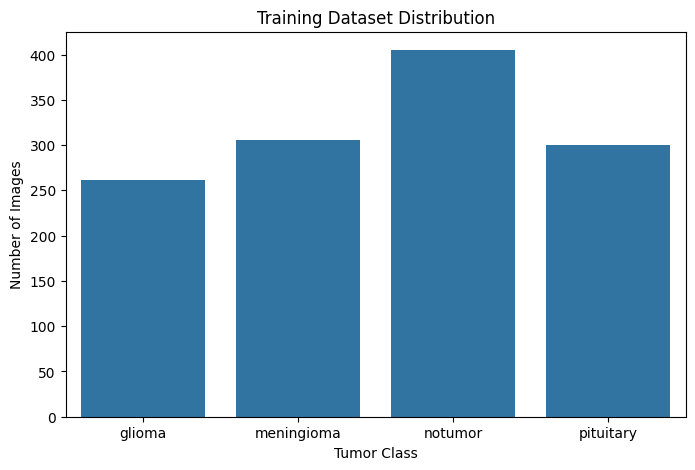

In [9]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=list(train_counts.keys()),
    y=list(test_counts.values()),
)

plt.title("Training Dataset Distribution")
plt.ylabel("Number of Images")
plt.xlabel("Tumor Class")
plt.show()

Display Sample MRI Images

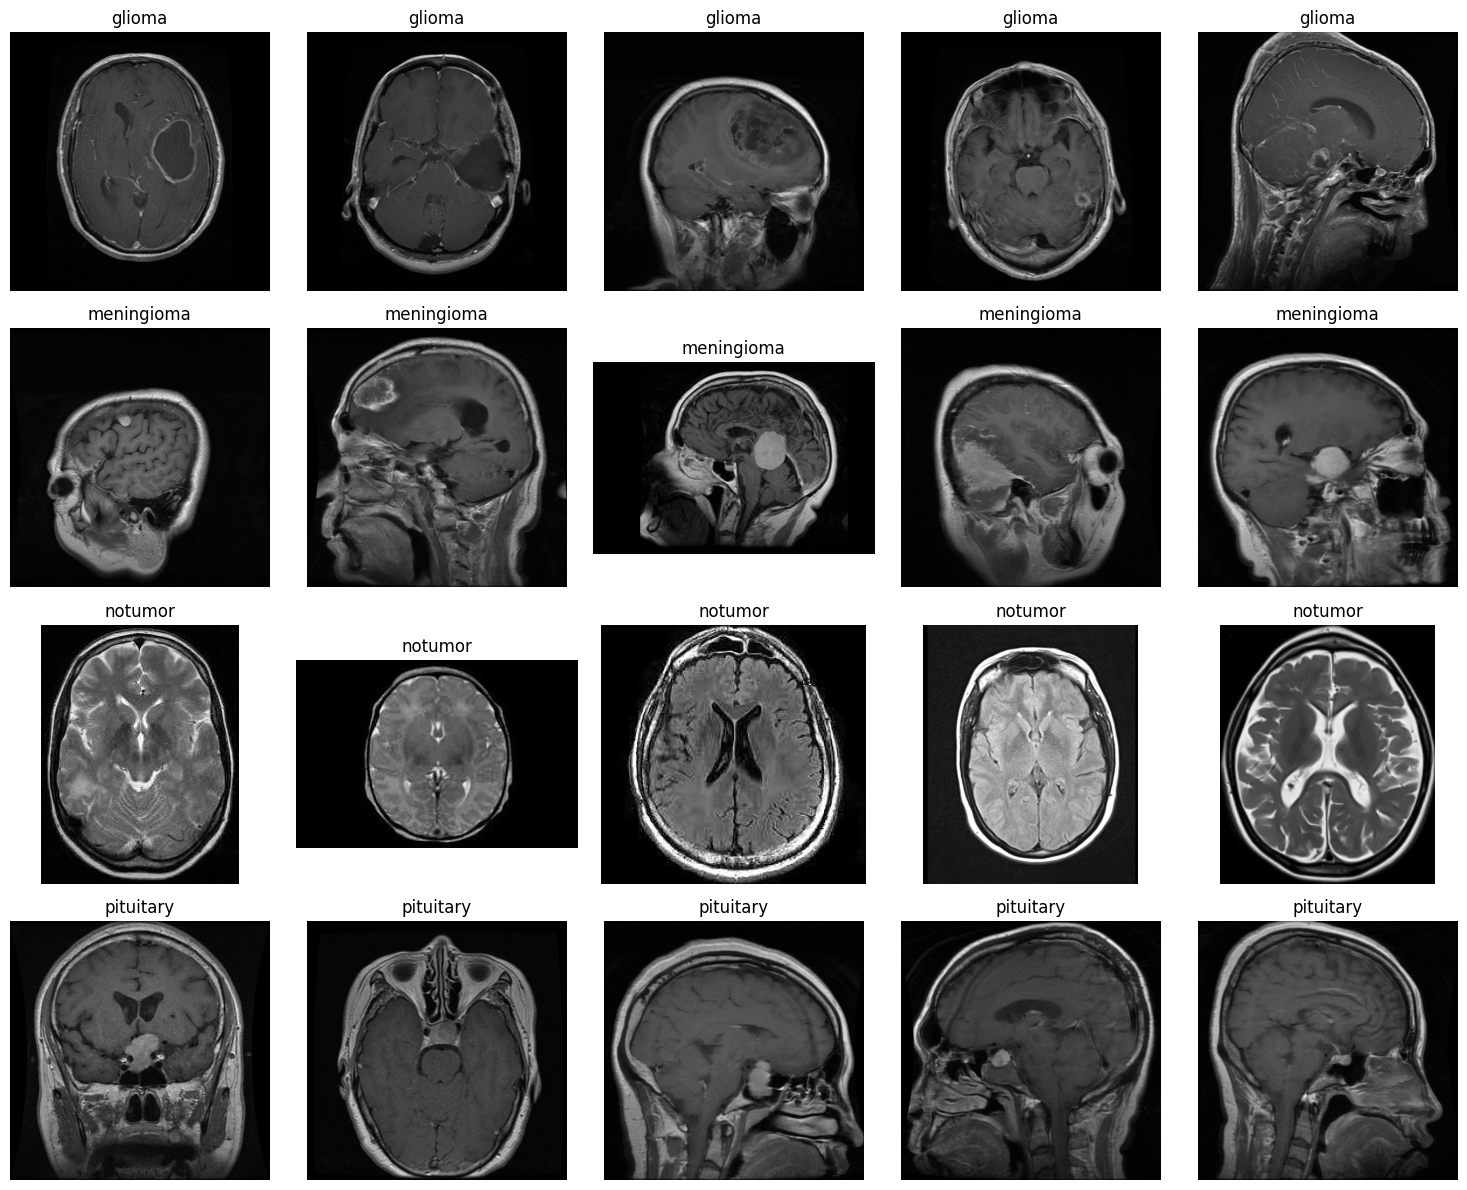

In [13]:
import random

fig, axes = plt.subplots(4, 5, figsize=(15,12))

for row, cls in enumerate(classes):

    class_path = os.path.join(train_dir, cls)

    images = random.sample(os.listdir(class_path), 5)

    for col, img_name in enumerate(images):
        img_path = os.path.join(class_path, img_name)
        img  = Image.open(img_path)

        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].set_title(cls)
        axes[row, col].axis("Off")

plt.tight_layout()
plt.show()


Check Image Dimensions

In [14]:
sizes = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(class_path)[:50]:
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)
        sizes.append(img.size)

print("Sample Image Sizes:", set(sizes))

Sample Image Sizes: {(630, 630), (350, 350), (502, 502), (236, 218), (234, 224), (206, 244), (721, 903), (442, 442), (1365, 1365), (400, 442), (393, 400), (360, 378), (236, 236), (512, 512), (236, 251), (562, 592), (224, 286), (685, 681), (1024, 830), (220, 212), (355, 452), (254, 198), (235, 233), (1280, 1280), (470, 432), (359, 449), (470, 508), (202, 202), (411, 501), (468, 444), (201, 210), (940, 900), (236, 280), (225, 225), (235, 229), (474, 474), (236, 295), (605, 613), (900, 741), (680, 680), (400, 400), (332, 442)}


In [17]:
pd.DataFrame(set(sizes))

,0,1
0,630,630
1,350,350
2,502,502
3,236,218
4,234,224
5,206,244
6,721,903
7,442,442
8,1365,1365
9,400,442
